In [189]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf
import sklearn
import scipy 
import linearmodels.panel as lmp
import semopy 
import seaborn as sns
import graphviz
import warnings
from semopy import calc_stats
from scipy.linalg import eigh, cholesky
from scipy.stats import norm
from factor_analyzer import FactorAnalyzer
from sklearn.decomposition import PCA
from IPython.display import Image
from stepmix.stepmix import StepMix
from pylab import plot, show, axis, subplot, xlabel, ylabel, grid

%matplotlib inline
warnings.filterwarnings("ignore")

Preguntas:

1. Cargue la base de datos y realice los ajustes necesarios para su uso (missing values, recodificar variables, etcetera). Identifique los tipos de datos que se encuentran en la base, realice estadisticas descriptivas sobre las variables importantes (Hint: Revisar la distribuciones, datos faltantes, outliers, etc.) y limpie las variables cuando sea necesario.

**R:** Se revisaron y eliminaron los valores faltantes (NaN) para evitar problemas en los análisis posteriores.
El dataset contiene variables correspondientes a información sociodemográfica, conductual y de contexto escolar. A partir de este, se generaron estadísticas descriptivas para verfificar las distribuciones, posteriormente detectar outliers.

En el caso de variables como IMCE y edad, los valores atípicos podrían representar casos reales de variabilidad dentro de la población, como niños con IMCE extremadamente bajo o alto (posible bajo peso o sobrepeso), lo cual es informativo para el análisis y no se quiso eliminar sin justificación teórica. 

La variable sk7 se buscó ajustar para que siguiese el sentido lógico de las demás pregutas, pero posteriormente se descartó, dado que no se utilizó dicha variable.
También se crearon nuevas variables derivadas de las ya existentes, para facilitar el análisis, como el tamaño del hogar y la edad en años, pero finalmente fueron descartadas.

In [190]:
df = pd.read_csv('junaeb3.csv', delimiter=",", decimal=',')

#PARA Q SEA POSITIVO
# df['sk7'] = 6 - df['sk7']
df['imce'] = pd.to_numeric(df['imce'], errors='coerce')
df.dropna(inplace=True)

In [191]:
df['Tamaño_hogar'] = df['vive_padre'] + df['vive_madre']
df['Tamaño_hogar'].describe()
df['Tamaño_hogar'].value_counts()

Tamaño_hogar
2    20907
1     8436
0      314
3       39
Name: count, dtype: int64

In [192]:
df['edad_años']=df['edad']/12

In [193]:
df['edad'].describe()

count    29696.000000
mean        82.544450
std          4.295051
min         62.000000
25%         80.000000
50%         81.000000
75%         82.000000
max        107.000000
Name: edad, dtype: float64

In [194]:
df['edad_años'].describe()

count    29696.000000
mean         6.878704
std          0.357921
min          5.166667
25%          6.666667
50%          6.750000
75%          6.833333
max          8.916667
Name: edad_años, dtype: float64

In [195]:
df0 = df[df.columns[pd.Series(df.columns).str.startswith(('sk','AcceptedCmpOverall','Num'))]]
#df0 = df0.drop(['skTotal','skRegularProds'], axis=1)
df1 = df[df.columns[pd.Series(df.columns).str.startswith(('sk','Num'))]]
df2  = (df1-df1.mean())/df1.std()

df1.describe()

,sk1,sk2,sk3,sk4,sk5,sk6,sk7,sk8,sk9,sk10,sk11,sk12,sk13
count,29696.000000,29696.000000,29696.000000,29696.000000,29696.000000,29696.000000,29696.000000,29696.000000,29696.000000,29696.000000,29696.000000,29696.000000,29696.000000
mean,1.108533,1.386651,1.256802,1.250943,1.264749,1.483803,2.228415,1.550748,1.326307,1.844693,1.379108,1.495858,1.687298
std,0.379168,0.643343,0.575636,0.569647,0.558138,0.734547,1.209599,0.827738,0.655108,0.933154,0.660226,0.790316,0.979401
min,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
50%,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2.000000,1.000000,1.000000,2.000000,1.000000,1.000000,1.000000
75%,1.000000,2.000000,1.000000,1.000000,1.000000,2.000000,3.000000,2.000000,1.000000,2.000000,2.000000,2.000000,2.000000
max,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000


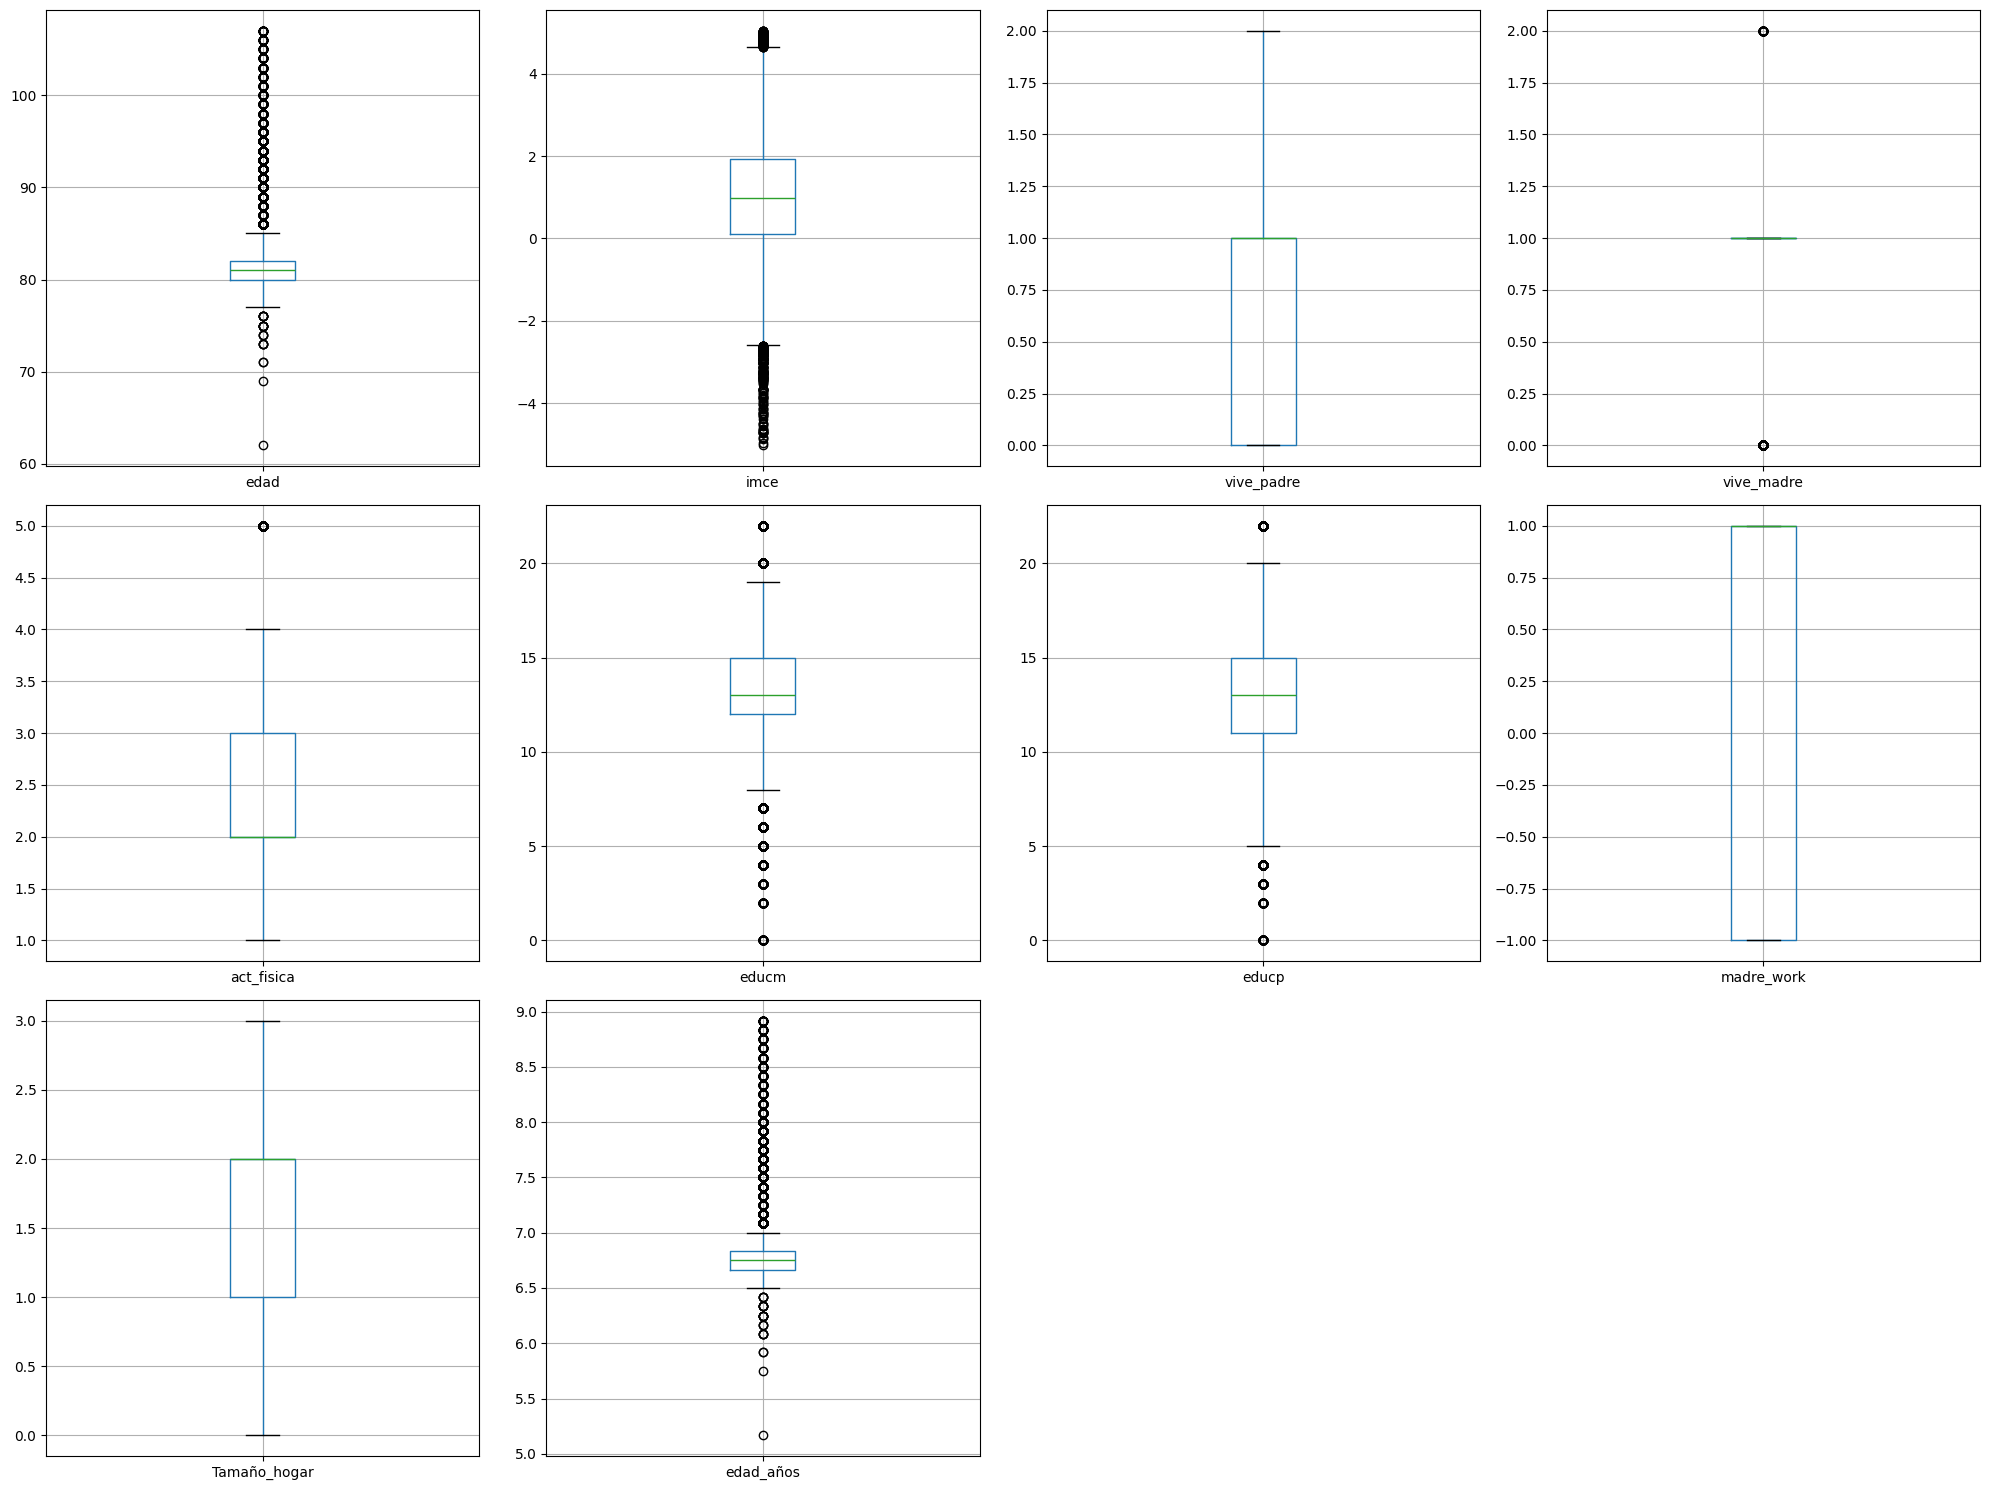

In [196]:
# Filtramos las columnas que no comienzan con 'sk' y excluimos la columna 'edad'
df_filtered = df.loc[:, ~df.columns.str.startswith('sk')]
df_filtered = df_filtered.drop(columns=['sexo', 'area'], errors='ignore')

# Número de subgráficos según el número de columnas restantes
n = len(df_filtered.columns)

# Calculamos el número de filas y columnas (máximo 4 columnas por fila)
ncols = 4
nrows = int(np.ceil(n / ncols))

# Creamos el gráfico con tantas filas y columnas como sea necesario
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(5 * ncols, 5 * nrows))

# Aplanamos el arreglo de ejes para que sea más fácil iterar
axes = axes.flatten()

# Crear un boxplot para cada columna
for i, column in enumerate(df_filtered.columns):
    df_filtered.boxplot(column=column, ax=axes[i])

# Si hay subgráficos vacíos (cuando no es múltiplo de 4), los eliminamos
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

In [197]:
df = df.drop(columns=['edad_años', 'Tamaño_hogar'])

2. A partir de las variables sk1-sk13 realice un EFA. En particular determine el numero optimo de factores y reporte las variables que se asocian a cada factor (usando los factor loadings). Tambien discuta si existen variables que no son informativas. (Hint: para realizar un EFA, todas las variables deben estar representatadas en el mismo sentido logico. Si una carateristica es negativa debe ser invertida en la escala, de tal forma que todas las variables representen aspectos positivos).

Análisis Factorial Exploratorio

Antes del EFA, se verificó que todas las variables tuvieran el mismo sentido lógico, es decir, que valores altos representaran siempre características positivas Como ya se mencionó anteriormente se obvió sk7, ya que no se consideraría posteriormente.

Para obtener el número "óptimo" de factores se utilizó el método del codo a partir de lo eigenvalues y se determinó que se usarían 3 factores.

Luego, se analizaron las comunalidades y los loadings de cada variable. En este análisis, la variable sk7 presentó una baja comunalidad y cargas factoriales poco significativas en todos los factores, lo que indica que no aporta información relevante en la estructura factorial encontrada y podría eliminarse del modelo en futuros análisis.

Tras revisar los ítems agrupados en cada factor y analizando el contenido de las variables, se propusó la siguiente interpretación para cada factor:

- Factor 1: Curiosos \
Este factor agrupa las variables sk9 (hace preguntas a adultos), sk10 (interés por libros), sk11 (interés por el entorno), sk12 (juega a armar/desarmar cosas) y sk13 (expresiones artísticas). 

- Factor 2: Expresivos \
Compuesto por sk1 (muestra afecto a padres), sk2 (afecto a pares), sk3 (expresa sentimientos), sk4 (usa gestos para mostrar sentimientos). 

- Factor 3: Extrovertidos \
Agrupa sk5 (juega con otros), sk6 (comparte sus cosas) y sk8 (participa en juegos grupales).

La variable sk7 no mostró asociación clara con ningún factor, lo que sugiere que puede no ser informativa. (esto resultó de la misma forma al invertir su sentido y al dejarla como venía originalmente).

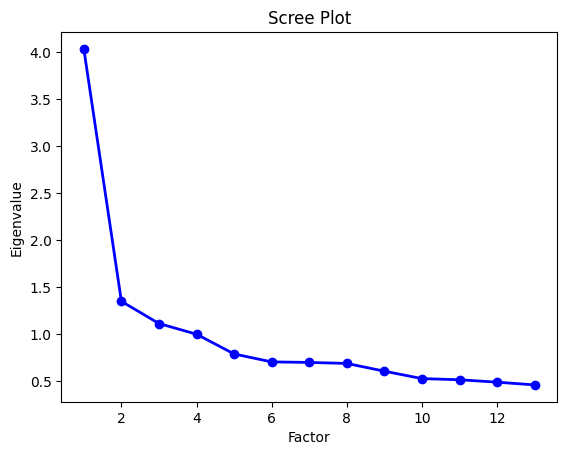

In [198]:
# Create factor analysis object and perform factor analysis
fa = FactorAnalyzer(rotation='varimax').fit(df1)

values = np.arange(1,14)
eigenvalues = pd.DataFrame(data=fa.get_eigenvalues())
plt.plot(values, eigenvalues.loc[0], 'o-', linewidth=2, color='blue')
plt.title('Scree Plot')
plt.xlabel('Factor')
plt.ylabel('Eigenvalue')
plt.show()

Dado a resultados posteriores se decidío por usar 3 factores

In [199]:
# MATRIZ DE PESOS
np.set_printoptions(suppress=True, formatter={'float_kind':'{:f}'.format})
fa.loadings_

array([[0.171221, 0.540217, 0.151458],
       [0.174149, 0.512531, 0.354330],
       [0.179785, 0.587108, 0.161938],
       [0.195805, 0.685256, 0.194526],
       [0.121301, 0.214133, 0.716727],
       [0.162524, 0.203313, 0.486711],
       [0.070301, 0.074530, 0.146613],
       [0.269211, 0.097481, 0.478541],
       [0.495887, 0.205273, 0.201636],
       [0.555989, 0.121166, 0.127875],
       [0.665920, 0.206954, 0.202009],
       [0.524127, 0.109526, 0.141501],
       [0.480548, 0.151480, 0.131725]])

* Las variables 1, 2, 3 y 4 pertenecen al factor 2.
* Las variables 5, 6 y 8 pertenecen al factor 3.
* Las variables 9, 10, 11, 12 y 13 pertenecen al factor 1.
* La variable 7 no pertenece claramente a ningún factor.

In [200]:
#  Para ver la cantidad de factores >1
# Obtener los eigenvalues
eigenvalues = fa.get_eigenvalues()

# Obtener las comunalidades
communalities = fa.get_communalities()

# Obtener la varianza explicada por cada factor
factor_variance = fa.get_factor_variance()

# Mostrar los resultados
print("Eigenvalues:", eigenvalues)
print(" ")
print("- - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - -")
print(" ")
print("Comunalidades:", communalities)
print(" ")
print("- - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - -")
print(" ")
print("Factor Variance:", factor_variance)


Eigenvalues: (array([4.034140, 1.350905, 1.114858, 1.001343, 0.791246, 0.707033,
       0.701430, 0.690630, 0.608183, 0.529379, 0.517172, 0.491397,
       0.462285]), array([3.438847, 0.745863, 0.522710, 0.217186, 0.117540, 0.062923,
       0.007478, -0.011080, -0.034611, -0.063772, -0.082158, -0.084646,
       -0.128859]))
 
- - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - -
 
Comunalidades: [0.344091 0.418566 0.403242 0.545755 0.574264 0.304637 0.031992 0.310979
 0.328698 0.340157 0.527086 0.306728 0.271224]
 
- - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - -
 
Factor Variance: (array([1.752965, 1.605630, 1.348825]), array([0.134843, 0.123510, 0.103756]), array([0.134843, 0.258353, 0.362109]))


3. Con los resultados de la Pregunta 2, graficamente indique si existen diferencias significativas en la distribucion de los factores usando las siguientes variables para caracterizar: sexo, area, imce y act_fisica (Hint: usar scatterplot de factores en pares, y ocupar la opcion 'hue' para agregar variables de caracterizacion). Que puede concluir de los resultados?

Utilizando los puntajes de los tres factores obtenidos en el análisis factorial exploratorio (EFA), se analizaron las diferencias en su distribución con respecto a las variables de caracterización: sexo, área de residencia, índice de masa corporal estandarizado (IMCE) y actividad física.

Para visualizar las diferencias entre grupos, se generaron gráficos de dispersión por pares de factores, se incoporó cada variable de caracterización como color. 

Los análisis gráficos realizados para explorar las diferencias en la distribución de los factores según las variables de caracterización sexo, área, IMCE y actividad física no mostraron diferencias significativas o claras entre los grupos. 
En cuanto al sexo, los gráficos mostraron que no hay grandes diferencias en la distribución de los factores entre hombres y mujeres. De igual forma, no se encontraron diferencias significativas en la distribución de los factores entre estudiantes de zonas urbanas y rurales. Al analizar el IMCE, los gráficos indicaron que los factores no se agruparon de manera clara según el estado nutricional de los estudiantes. Finalmente, respecto a la actividad física, no se observó ninguna tendencia evidente en la distribución de los factores. 
Como ya se mencionó anteriormente, las diferencias entre los grupos según estas variables de caracterización son mínimas, lo que sugiere que los factores son relativamente similares entre los diferentes grupos (sexo, área, IMCE, y actividad física).

In [201]:
factores = fa.transform(df1)
df3=df.copy()
factores_df = pd.DataFrame(factores, columns=["Factor 1", "Factor 2", "Factor 3"])

df3['Factor 1'] = factores_df['Factor 1']
df3['Factor 2'] = factores_df['Factor 2']
df3['Factor 3'] = factores_df['Factor 3']

In [202]:
df3['imce'] = pd.to_numeric(df3['imce'], errors='coerce')

# Luego, aplicar pd.cut para clasificar los valores
df3['imc'] = pd.cut(df3['imce'], 
                   bins=[-float('inf'), -1, 1, float('inf')], 
                   labels=['Bajo peso', 'Normal', 'Sobrepeso'])

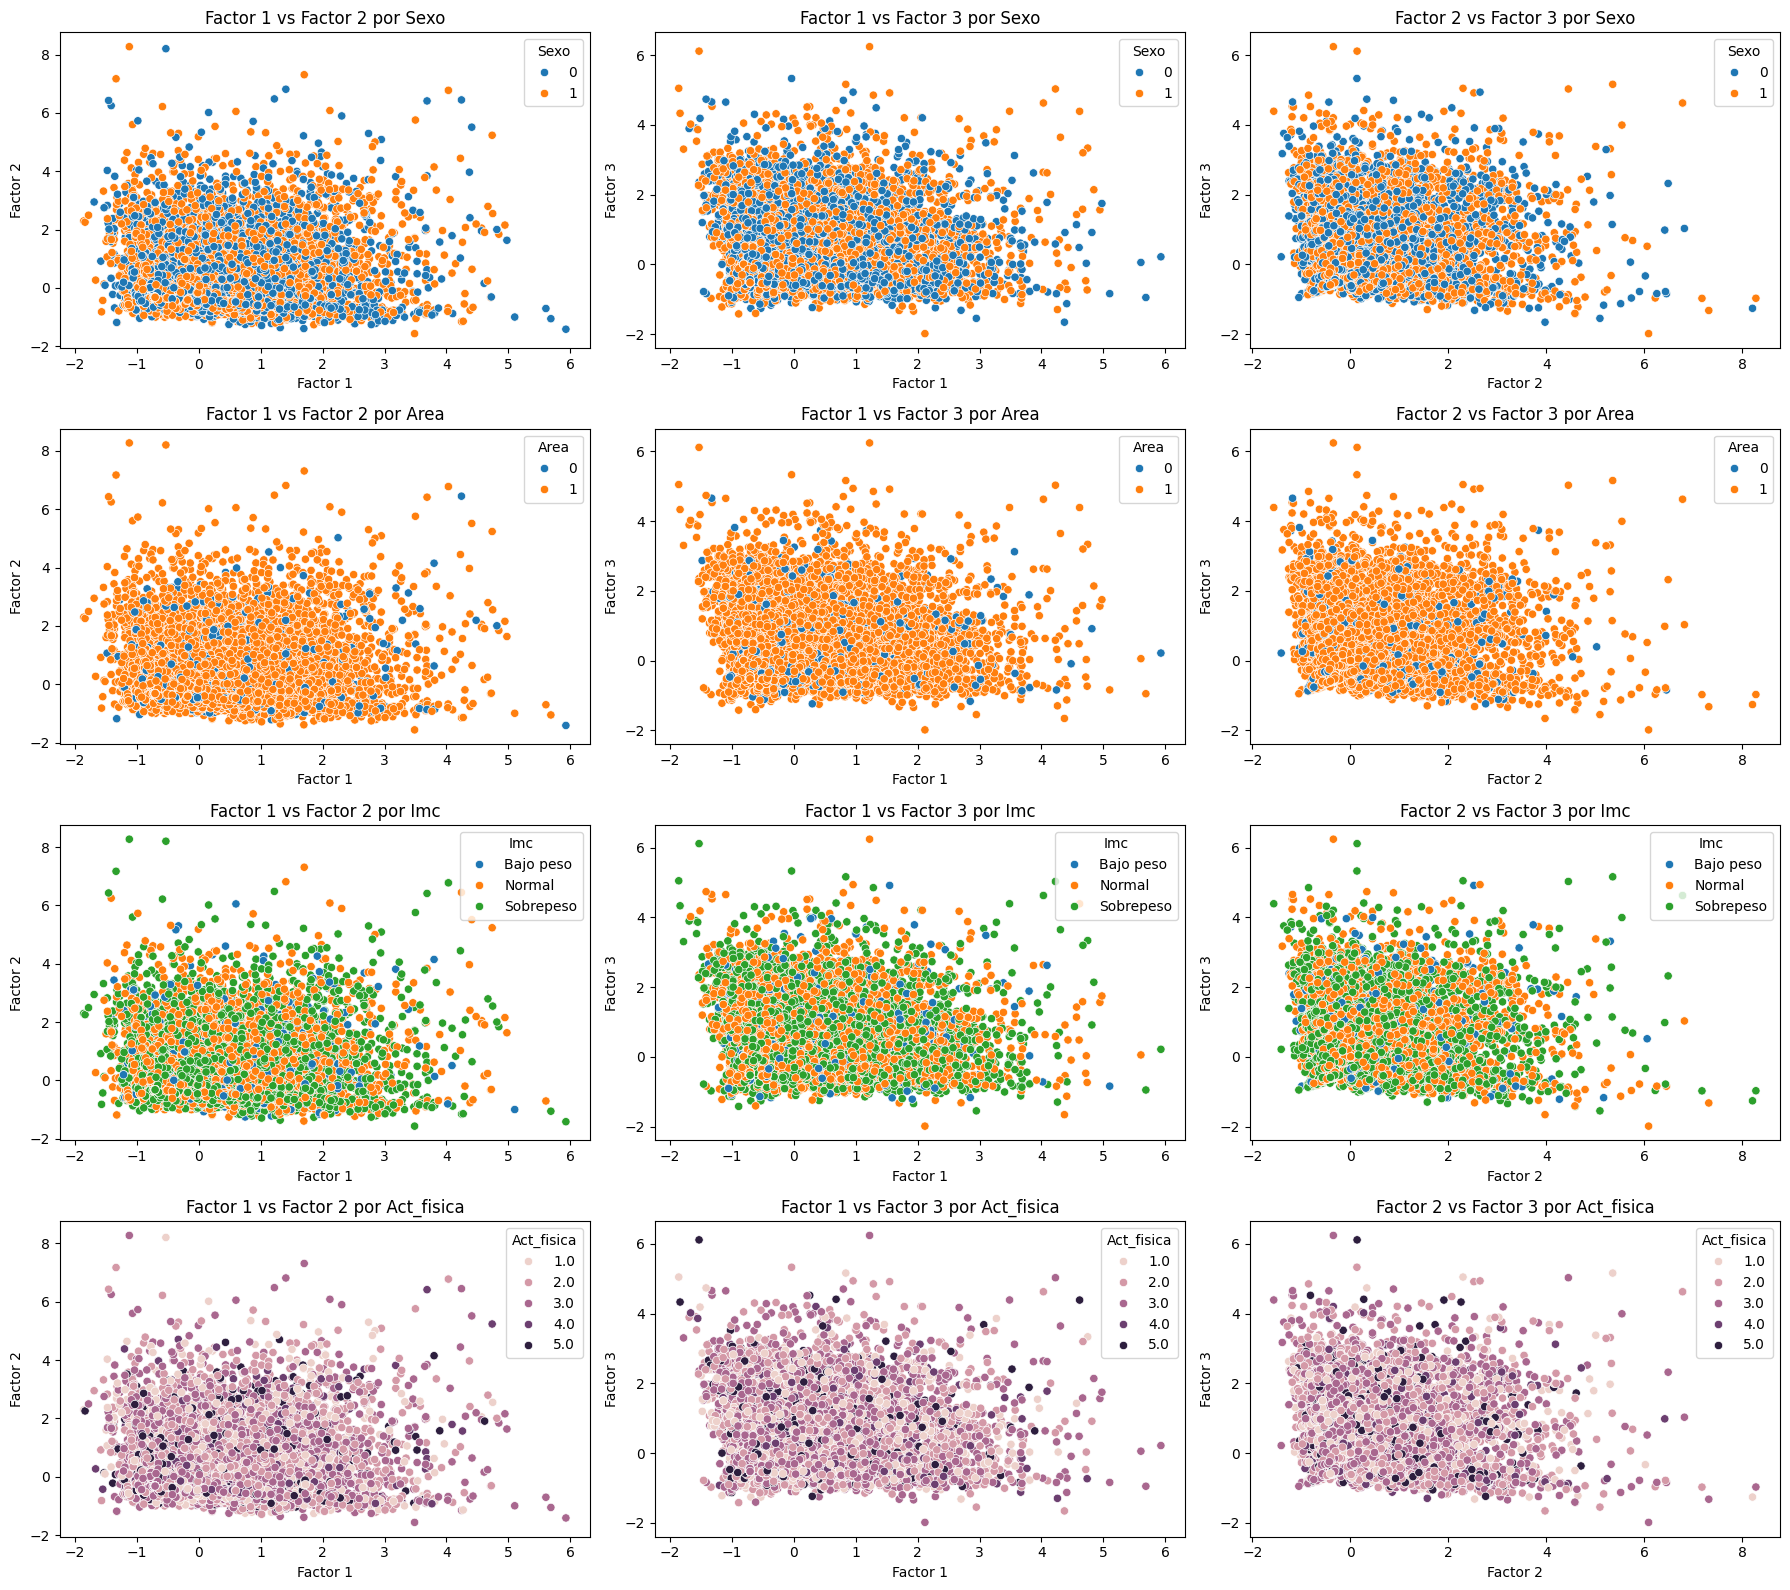

In [203]:
# Lista de las variables de caracterización
Variables = ['sexo', 'area', 'imc', 'act_fisica']

# Definir el número de filas y columnas para los subgráficos
# En este caso, asumimos 4 variables y 3 combinaciones de factores por variable
fig, axes = plt.subplots(nrows=4, ncols=3, figsize=(18, 16))

# Flatten the axes array for easier iteration
axes = axes.flatten()

# Iterar sobre las variables y graficar en los subgráficos
for idx, var in enumerate(Variables):
    # Graficar Factor 1 vs Factor 2, usando la variable de la lista como 'hue'
    sns.scatterplot(data=df3, x='Factor 1', y='Factor 2', hue=var, ax=axes[idx*3])
    axes[idx*3].set_title(f'Factor 1 vs Factor 2 por {var.capitalize()}')
    axes[idx*3].set_xlabel('Factor 1')
    axes[idx*3].set_ylabel('Factor 2')
    axes[idx*3].legend(title=var.capitalize())

    # Graficar Factor 1 vs Factor 3, usando la variable de la lista como 'hue'
    sns.scatterplot(data=df3, x='Factor 1', y='Factor 3', hue=var, ax=axes[idx*3 + 1])
    axes[idx*3 + 1].set_title(f'Factor 1 vs Factor 3 por {var.capitalize()}')
    axes[idx*3 + 1].set_xlabel('Factor 1')
    axes[idx*3 + 1].set_ylabel('Factor 3')
    axes[idx*3 + 1].legend(title=var.capitalize())

    # Graficar Factor 2 vs Factor 3, usando la variable de la lista como 'hue'
    sns.scatterplot(data=df3, x='Factor 2', y='Factor 3', hue=var, ax=axes[idx*3 + 2])
    axes[idx*3 + 2].set_title(f'Factor 2 vs Factor 3 por {var.capitalize()}')
    axes[idx*3 + 2].set_xlabel('Factor 2')
    axes[idx*3 + 2].set_ylabel('Factor 3')
    axes[idx*3 + 2].legend(title=var.capitalize())

# Ajustar el layout para que los gráficos no se solapen
plt.tight_layout()

# Mostrar los gráficos
plt.show()

No hay relación

4. Con los resultados obtenidos en la Pregunta 2, proponga un CFA donde cada variable solo se asocia con un factor. Entregue un nombre a cada factor que representa el concepto comun entre las variables incluidas. Reporte la importancia de cada medida (variable) a cada factor e indique la correlacion entre factores (loadings). 

**R:** Las variables asociadas a cada factor fueron las mismas definidas en la pregunta 2, con sus respectivos nombres:\
- Factor 1: Curiosos \
Este factor agrupa las variables sk9 (hace preguntas a adultos), sk10 (interés por libros), sk11 (interés por el entorno), sk12 (juega a armar/desarmar cosas) y sk13 (expresiones artísticas). 

- Factor 2: Expresivos \
Compuesto por sk1 (muestra afecto a padres), sk2 (afecto a pares), sk3 (expresa sentimientos), sk4 (usa gestos para mostrar sentimientos). 

- Factor 3: Extrovertidos \
Agrupa sk5 (juega con otros), sk6 (comparte sus cosas) y sk8 (participa en juegos grupales).

Las correlaciones entre los factores fueron moderadas, con valores que van desde 0.58 hasta 0.65, lo que significa que, aunque los factores están algo relacionados entre sí, cada uno sigue representando una dimensión distinta. Esto sugiere que cada factor aporta información única y útil para los análisis que se realizarán más adelante.

Por otro lado, el modelo mostró un buen ajuste según los principales índices reportados (podemos concluir que el modelo es válido y adecuado):
- CFI: 0.95 (>0.9)\
- TLI: 0.93 (>0.9)\
- RMSEA: 0.05

In [204]:
mod = """
eta2 =~ sk1 + sk2 + sk3 + sk4  #Expresivos 
eta3 =~ sk5 + sk6 + sk8  #Extrovertidos
eta1 =~ sk9 + sk10 + sk11 + sk12 + sk13  #Curiosos
"""
# Crear y ajustar el modelo SEM con semopy
model = semopy.Model(mod)
out = model.fit(df1) 

# Imprimir los resultados del modelo
print(out)

Name of objective: MLW
Optimization method: SLSQP
Optimization successful.
Optimization terminated successfully
Objective value: 0.143
Number of iterations: 41
Params: 1.877 1.646 1.846 1.020 1.158 1.348 1.248 1.097 1.274 0.152 0.049 0.051 0.057 0.161 0.091 0.095 0.595 0.200 0.442 0.713 0.242 0.199 0.158 0.151 0.372 0.469 0.277


In [205]:
# Inspeccionar los resultados y obtener los parámetros estandarizados
model.inspect(mode='list', what="names", std_est=True)

,lval,op,rval,Estimate,Est. Std,Std. Err,z-value,p-value
0,sk1,~,eta2,1.000000,0.582652,-,-,-
1,sk2,~,eta2,1.876642,0.644548,0.023793,78.87212,0.0
2,sk3,~,eta2,1.646084,0.631816,0.021121,77.934883,0.0
3,sk4,~,eta2,1.845637,0.715782,0.022169,83.253688,0.0
4,sk5,~,eta3,1.000000,0.718118,-,-,-
5,sk6,~,eta3,1.019985,0.556582,0.01433,71.178266,0.0
6,sk8,~,eta3,1.158490,0.560988,0.016193,71.542093,0.0
7,sk9,~,eta1,1.000000,0.594425,-,-,-
8,sk10,~,eta1,1.348296,0.562596,0.01854,72.725071,0.0
9,sk11,~,eta1,1.247906,0.736003,0.014736,84.684717,0.0


In [206]:
semopy.calc_stats(model)
# rmsea menor (alto) y TLI alto

,DoF,DoF Baseline,chi2,chi2 p-value,chi2 Baseline,CFI,GFI,AGFI,NFI,TLI,RMSEA,AIC,BIC,LogLik
Value,51,66,4252.869542,0.0,80903.16637,0.948021,0.947433,0.931972,0.947433,0.932733,0.052674,53.713573,277.780299,0.143214


In [207]:
# Obtener las estimaciones del modelo
estimates = model.inspect(mode='list', what="names", std_est=True)

# Filtrar las correlaciones entre factores latentes
factor_corrs = estimates[
    (estimates['op'] == '~~') &  # Correlaciones entre factores (op == '~~')
    (estimates['lval'].str.contains('eta')) &  # 'eta' representa factores latentes
    (estimates['rval'].str.contains('eta')) &  # Ambos lados deben ser factores latentes
    (estimates['lval'] != estimates['rval'])  # Excluir varianzas, solo correlaciones
]

# Imprimir las correlaciones entre factores
print(factor_corrs)

# Obtener las varianzas de los factores (donde lval == rval)
covs = estimates[
    (estimates['op'] == '~~') &  # Correlaciones entre factores (op == '~~')
    (estimates['lval'].str.contains('eta')) &  # 'eta' representa factores latentes
    (estimates['rval'].str.contains('eta'))
]

# Crear un diccionario con las varianzas
vars_dict = {
    row['lval']: row['Estimate']  # Guardar solo la varianza (donde lval == rval)
    for idx, row in covs.iterrows()
    if row['lval'] == row['rval']
}

# Calcular las correlaciones manualmente
for idx, row in covs.iterrows():
    if row['lval'] != row['rval']:  # Evitar las varianzas
        eta1, eta2 = row['lval'], row['rval']
        var1, var2 = vars_dict[eta1], vars_dict[eta2]
        
        # Calculando la correlación como covarianza / (sqrt(var1) * sqrt(var2))
        corr = row['Estimate'] / (var1 ** 0.5 * var2 ** 0.5)
        print(f"Corr({eta1}, {eta2}) = {corr:.3f}")


    lval  op  rval  Estimate  Est. Std  Std. Err    z-value p-value
14  eta2  ~~  eta1  0.051246  0.595708  0.000964  53.168467     0.0
15  eta2  ~~  eta3  0.057314  0.647256  0.000996  57.558878     0.0
17  eta3  ~~  eta1  0.091020  0.583238  0.001668  54.579612     0.0
Corr(eta2, eta1) = 0.596
Corr(eta2, eta3) = 0.647
Corr(eta3, eta1) = 0.583


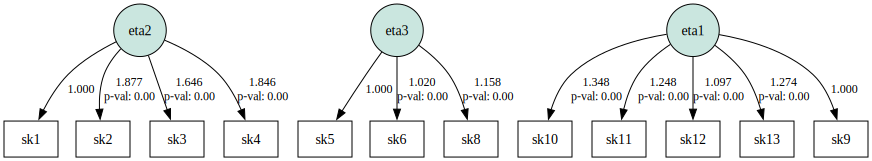

In [208]:
import os
os.environ["PATH"] += os.pathsep + r"C:\Program Files\Graphviz\bin"

semopy.semplot(model, "4-semmodel.png")

Cofirma el ajuste, ya que los índices son buenos

5. Estime un modelo de clases latentes usando imce via StepMix. Determine el numero optimo de clases (clusters) y muestre las diferencias entre clusters graficamente. Que se puede concluir de los resultados?

**R**: Se estimaron modelos de clases latentes utilizando IMCE como variable principal, aplicando los métodos gaussian y gaussian_diag con 3 y 4 clusters.

Los modelos fueron comparados en base a dos criterios principales, BIC y entropía:

Para gaussian_diag:
- Con 3 clusters, el BIC fue 102762.06 y la entropía fue 22029.9267.
- Con 4 clusters, el BIC fue 102795.56 y la entropía fue 32867.55

Para gaussian:
- Con 3 clusters, el BIC fue 102780.14 y la entropía fue 11499.49.
- Con 4 clusters, el BIC fue 102744.24 y la entropía fue 22265.79.

Además, para complementar se visualizó la distribución de IMCE en cada uno de los clusters generados con los modelos gaussian y gaussian_diag. Ambos gráficos mostraron una mejor separación de los clusters cuando se utilizaron 3 clusters, siendo aún más evidente para gaussian_diag.

Con todo esto se concluyó que el modelo con 3 clusters es el óptimo, ya que muestra una mejor clasificación de las observaciones en general, basadandose en el BIC y en la entropía (Ambos modelos con 4 clusters presentó una entropía peor, por lo que no fueron seleccionados como el modelo óptimo).

Con esta segmentación en tres grupos se identificó a tres perfiles según el imce: bajo peso, peso normal, sobrepeso/obesidad.

En cuanto al anáisis gráfico, los gráficos de boxplot, violín y densidad muestran claramente las diferencias en la distribución de IMCE entre los clusters generados por el modelo de clases latentes:

- Cluster 0 (bajo peso) tiene un IMCE bajo, con una distribución centrada cerca de cero y algunos outliers.

- Cluster 1 (peso normal) muestra una distribución más ancha y dispersa, reflejando mayor variabilidad en los valores de IMCE.

- Cluster 2 (sobrepeso/obesidad) tiene un IMCE alto, con una distribución estrecha y concentrada en valores elevados.

El gráfico de densidad refuerza estas diferencias, mostrando que cada cluster tiene una distribución distinta de IMCE, con una clara separación entre ellos.

Los gráficos confirman que los 3 clusters generados por el modelo muestran diferencias significativas en IMCE, lo que justifica la segmentación.


In [209]:
df2=df[['imce']]

#### Comparación con 3 y 4 Cluter, tanto con Gaussian_diag como con Gaussian

In [210]:
# Numero optimo de clusters
K = range(2, 10)
fits = []
BIC = []

for k in K:
    # train the model for current value of k on training data
    model = StepMix(n_components=k, measurement='gaussian', verbose=0, random_state=123).fit(df2)
    
    # append the model to fits
    fits.append(model)
    
    # Append the silhouette score to scores
    BIC.append(model.sabic(df2))

Fitting StepMix...


Initializations (n_init) : 100%|██████████| 1/1 [00:01<00:00,  1.43s/it, max_LL=-5.18e+4, max_avg_LL=-1.74]


Fitting StepMix...


Initializations (n_init) : 100%|██████████| 1/1 [00:04<00:00,  4.18s/it, max_LL=-5.14e+4, max_avg_LL=-1.73]


Fitting StepMix...


...

Initializations (n_init) : 100%|██████████| 1/1 [00:12<00:00, 12.53s/it, max_LL=-5.13e+4, max_avg_LL=-1.73]


Fitting StepMix...


Initializations (n_init) : 100%|██████████| 1/1 [00:13<00:00, 13.77s/it, max_LL=-5.13e+4, max_avg_LL=-1.73]


Fitting StepMix...


Initializations (n_init) : 100%|██████████| 1/1 [00:19<00:00, 19.31s/it, max_LL=-5.13e+4, max_avg_LL=-1.73]


<Axes: >

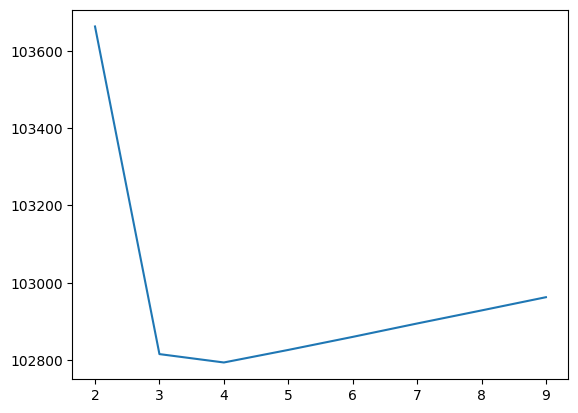

In [211]:
sns.lineplot(x = K, y = BIC)  

In [212]:
# Numero optimo de clusters
K = range(2, 10)
fits = []
BIC = []

for k in K:
    # train the model for current value of k on training data
    model = StepMix(n_components=k, measurement='gaussian_diag', verbose=0, random_state=123).fit(df2)
    
    # append the model to fits
    fits.append(model)
    
    # Append the silhouette score to scores
    BIC.append(model.sabic(df2))

Fitting StepMix...


Initializations (n_init) : 100%|██████████| 1/1 [00:06<00:00,  6.67s/it, max_LL=-5.14e+4, max_avg_LL=-1.73]


Fitting StepMix...


Initializations (n_init) : 100%|██████████| 1/1 [00:06<00:00,  6.29s/it, max_LL=-5.13e+4, max_avg_LL=-1.73]


Fitting StepMix...


...

Initializations (n_init) : 100%|██████████| 1/1 [00:14<00:00, 14.20s/it, max_LL=-5.13e+4, max_avg_LL=-1.73]


Fitting StepMix...


Initializations (n_init) : 100%|██████████| 1/1 [00:14<00:00, 14.66s/it, max_LL=-5.13e+4, max_avg_LL=-1.73]


Fitting StepMix...


Initializations (n_init) : 100%|██████████| 1/1 [00:16<00:00, 16.55s/it, max_LL=-5.13e+4, max_avg_LL=-1.73]


<Axes: >

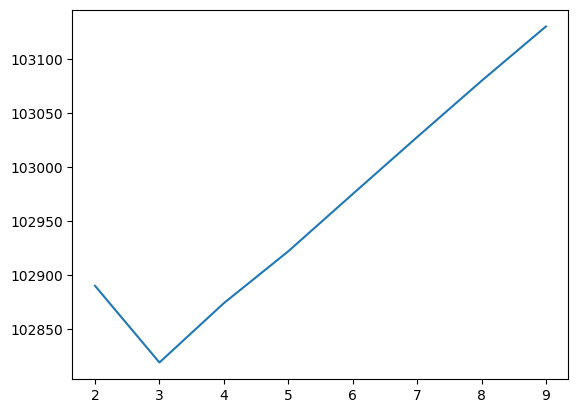

In [213]:
sns.lineplot(x = K, y = BIC)  

In [214]:
model = StepMix(n_components=4, measurement="gaussian_diag", verbose=1, random_state=123).fit(df2)

Fitting StepMix...


Initializations (n_init) : 100%|██████████| 1/1 [00:07<00:00,  7.59s/it, max_LL=-5.13e+4, max_avg_LL=-1.73]

MODEL REPORT
    Measurement model parameters
          model_name           gaussian_diag                        
          class_no                         0       1       2       3
          param       variable                                      
          covariances imce            1.5910  2.7312  1.5206  0.9168
          means       imce            1.5809 -0.1388  1.7591  0.4413
    Class weights
        Class 1 : 0.25
        Class 2 : 0.09
        Class 3 : 0.26
        Class 4 : 0.40
    Fit for 4 latent classes
    Estimation method             : 1-step
    Number of observations        : 29696
    Number of latent classes      : 4
    Number of estimated parameters: 11
    Log-likelihood (LL)           : -51341.1384
    -2LL                          : 102682.2768
    Average LL                    : -1.7289
    AIC                           : 102704.28
    BIC                           : 102795.56
    CAIC                          : 102806.56
    Sample-Size Adjusted BIC  

In [215]:
model = StepMix(n_components=4, measurement="gaussian", verbose=1, random_state=123).fit(df2)

Fitting StepMix...


Initializations (n_init) : 100%|██████████| 1/1 [00:07<00:00,  7.29s/it, max_LL=-5.13e+4, max_avg_LL=-1.73]

MODEL REPORT
    Measurement model parameters
          model_name     gaussian_unit                        
          class_no                   0       1       2       3
          param variable                                      
          means imce             1.173  2.7111 -2.5822  0.1384
    Class weights
        Class 1 : 0.49
        Class 2 : 0.16
        Class 3 : 0.01
        Class 4 : 0.35
    Fit for 4 latent classes
    Estimation method             : 1-step
    Number of observations        : 29696
    Number of latent classes      : 4
    Number of estimated parameters: 7
    Log-likelihood (LL)           : -51336.0764
    -2LL                          : 102672.1527
    Average LL                    : -1.7287
    AIC                           : 102686.15
    BIC                           : 102744.24
    CAIC                          : 102751.24
    Sample-Size Adjusted BIC      : 102794.09
    Entropy                       : 22265.7966
    Scaled Relative Entropy    

In [216]:
model = StepMix(n_components=3, measurement="gaussian_diag", verbose=1, random_state=123).fit(df2)

Fitting StepMix...


Initializations (n_init) : 100%|██████████| 1/1 [00:05<00:00,  5.98s/it, max_LL=-5.13e+4, max_avg_LL=-1.73]

MODEL REPORT
    Measurement model parameters
          model_name           gaussian_diag                
          class_no                         0       1       2
          param       variable                              
          covariances imce            0.9629  1.4229  2.7533
          means       imce            0.5012  1.8813 -0.0576
    Class weights
        Class 1 : 0.49
        Class 2 : 0.41
        Class 3 : 0.10
    Fit for 3 latent classes
    Estimation method             : 1-step
    Number of observations        : 29696
    Number of latent classes      : 3
    Number of estimated parameters: 8
    Log-likelihood (LL)           : -51339.8343
    -2LL                          : 102679.6686
    Average LL                    : -1.7288
    AIC                           : 102695.67
    BIC                           : 102762.06
    CAIC                          : 102770.06
    Sample-Size Adjusted BIC      : 102819.02
    Entropy                       : 22029.9267
 

In [217]:
model = StepMix(n_components=3, measurement="gaussian", verbose=1, random_state=123).fit(df2)

Fitting StepMix...


Initializations (n_init) : 100%|██████████| 1/1 [00:02<00:00,  2.91s/it, max_LL=-5.14e+4, max_avg_LL=-1.73]

MODEL REPORT
    Measurement model parameters
          model_name     gaussian_unit                
          class_no                   0       1       2
          param variable                              
          means imce            -1.949  2.4056  0.5984
    Class weights
        Class 1 : 0.02
        Class 2 : 0.27
        Class 3 : 0.71
    Fit for 3 latent classes
    Estimation method             : 1-step
    Number of observations        : 29696
    Number of latent classes      : 3
    Number of estimated parameters: 5
    Log-likelihood (LL)           : -51364.3251
    -2LL                          : 102728.6503
    Average LL                    : -1.7297
    AIC                           : 102738.65
    BIC                           : 102780.14
    CAIC                          : 102785.14
    Sample-Size Adjusted BIC      : 102815.75
    Entropy                       : 11499.4902
    Scaled Relative Entropy       : 0.6475


Grupo con 3 Clusters arrojó resultados mejores en general, en comparación con 4 clusters 

BOX PLOT

Fitting StepMix...


Initializations (n_init) : 100%|██████████| 1/1 [00:06<00:00,  6.19s/it, max_LL=-5.13e+4, max_avg_LL=-1.73]


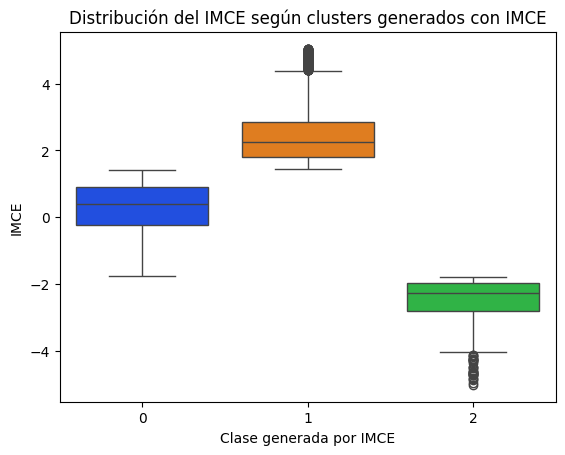

In [218]:
# Modelo ajustado con la variable imce
model_imce = StepMix(n_components=3, measurement="gaussian_diag", verbose=0, random_state=123)
model_imce.fit(df2)

df['imce_class'] = model_imce.predict(df2)

sns.boxplot(data=df, x='imce_class', y='imce', hue='imce_class', palette='bright', legend=False)
plt.title('Distribución del IMCE según clusters generados con IMCE')
plt.xlabel('Clase generada por IMCE')
plt.ylabel('IMCE')
plt.show()

VIOLIN PLOT

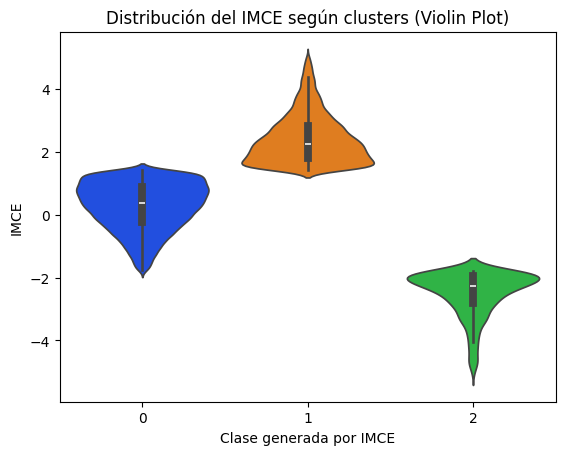

In [219]:
sns.violinplot(data=df, x='imce_class', y='imce', palette='bright')
plt.title('Distribución del IMCE según clusters (Violin Plot)')
plt.xlabel('Clase generada por IMCE')
plt.ylabel('IMCE')
plt.show()

DENSIDAD

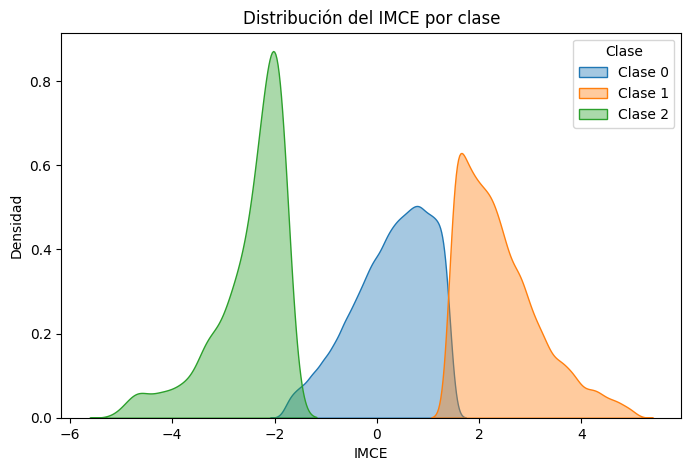

In [220]:
plt.figure(figsize=(8, 5))

for clase in sorted(df['imce_class'].unique()):
    subset = df[df['imce_class'] == clase]
    sns.kdeplot(subset['imce'], label=f'Clase {clase}', fill=True, alpha=0.4)

plt.title('Distribución del IMCE por clase')
plt.xlabel('IMCE')
plt.ylabel('Densidad')
plt.legend(title='Clase')
plt.show()

6. Implemente un SEM completo usando la estructura propuesta en la Pregunta 4. En particular, estime un modelo donde los factores latentes explican el imce, junto con otras variables que existen en la base de datos. Ademas utilice otras variables relevantes de la base de datos para su modelo. Las variables a incluir en el modelo final deben tener sustento teorico y el modelo final debe optimizar el ajuste a los datos, en base a los criterios vistos en clase (TLI, CLI, RMSEA). Que puede concluir en base a sus resultados?

**R:** Se probaron varios modelos SEM utilizando diferentes combinaciones de relaciones entre los factores latentes (eta1, eta2, eta3) y otras variables relevantes. Se exploraron distintas configuraciones de cómo los factores socioemocionales interactúan con variables como actividad física, edad, escolaridad materna y paterna, sexo, y presencia de los padres.

A lo largo de las pruebas, se encontraron combinaciones de variables que ofrecían mejores resultados de ajuste en términos de CFI, RMSEA y TLI. Sin embargo, algunas de estas combinaciones entregaban resultados poco lógicos, como la conclusión de que la actividad física no influye en el IMCE, lo cual no tiene sentido desde el punto de vista teórico y práctico.

El modelo SEM final fue ajustado utilizando las relaciones más consistentes teóricamente y que ofrecieron el mejor ajuste global. Los índices de ajuste fueron los siguientes:

- TLI: 0.769

- CFI: 0.806

- RMSEA: 0.0736

Estos valores indican un ajuste moderado del modelo, con un CFI "cercano" a 0.90 y un RMSEA no mucho mayor a 0.05. Aunque no alcanzan los estándares ideales de ajuste perfecto, los resultados son suficientes para una interpretación válida del modelo.

Los resultados del modelo SEM mostraron que:

Los factores latentes (eta1, eta2, eta3) tienen una influencia significativa sobre el IMCE. A pesar de que actividad física presentó una relación negativa significativa con el IMCE, en algunas configuraciones previas, el modelo indicaba que la actividad física no influía de manera directa en el IMCE. Este resultado fue ajustado en el modelo final, ya que tiene un impacto teórico importante sobre el IMCE.

La escolaridad materna y paterna mostraron efectos positivos significativos sobre los factores socioemocionales, sugiriendo que la educación de los padres influye en el desarrollo socioemocional de los estudiantes. Por otro lado, Las relaciones entre los factores latentes y las variables de residencia (vive_madre, vive_padre) también fueron significativas, pero con una influencia menor en el IMCE.

**Modelo gráfico**\
El modelo SEM final muestra claramente las relaciones entre los factores latentes y las variables observadas, así como las cargas factoriales de las variables en cada factor, todas ellas significativas. El modelo gráfico también revela la fuerza de las relaciones y el ajuste a los datos.

In [221]:
mod = """
eta1 =~ sk9 + sk10 + sk11 + sk12 + sk13 #Curiosos
eta2 =~ sk1 + sk2 + sk3 + sk4 #Expresivos 
eta3 =~ sk5 + sk6 + sk8 #Extrovertidos

imce =~ eta1 + eta2 + eta3 + act_fisica + edad + educm + educp 

# eta1 ~ vive_padre + vive_madre + 
# eta2 ~ vive_padre + vive_madre 
# eta3 ~ vive_padre 

eta1 ~ vive_padre + vive_madre
eta2 ~ vive_padre + vive_madre
eta3 ~ vive_padre 
"""

model_6 = semopy.Model(mod);
out = model_6.fit(df);
print(out)

print(" ")
print(" ")
stats = calc_stats(model_6)
print("CFI:", stats['CFI'])
print("- - - - - - - - - - - - -")
print("TLI:", stats['TLI'])
print("- - - - - - - - - - - - -")
print("RMSEA:", stats['RMSEA'])


Name of objective: MLW
Optimization method: SLSQP
Optimization successful.
Optimization terminated successfully
Objective value: 0.648
Number of iterations: 78
Params: 1.365 1.239 1.091 1.278 1.843 1.640 1.829 1.026 1.182 0.574 1.030 -0.582 3.068 -2.606 -2.477 -0.029 -0.073 -0.020 -0.019 -0.034 1.110 17.618 10.463 11.132 0.062 0.020 0.063 0.089 0.094 0.588 0.203 0.444 0.711 0.245 0.198 0.158 0.153 0.373 0.464 0.277
 
 
CFI: Value    0.806415
Name: CFI, dtype: float64
- - - - - - - - - - - - -
TLI: Value    0.770949
Name: TLI, dtype: float64
- - - - - - - - - - - - -
RMSEA: Value    0.070095
Name: RMSEA, dtype: float64


In [222]:
model_6.inspect(mode='list', what="names", std_est=True)

,lval,op,rval,Estimate,Est. Std,Std. Err,z-value,p-value
0,eta1,~,imce,1.000000,0.767472,-,-,-
1,eta2,~,imce,0.573638,0.769227,0.010489,54.687613,0.0
2,eta3,~,imce,1.030165,0.773940,0.017665,58.315082,0.0
3,eta1,~,vive_padre,-0.028524,-0.032940,0.005625,-5.071197,0.0
4,eta1,~,vive_madre,-0.073403,-0.030985,0.014251,-5.1507,0.0
5,eta2,~,vive_padre,-0.019751,-0.039852,0.003219,-6.13547,0.0
6,eta2,~,vive_madre,-0.019107,-0.014093,0.008142,-2.346749,0.018938
7,eta3,~,vive_padre,-0.034426,-0.038917,0.006116,-5.628428,0.0
8,sk9,~,eta1,1.000000,0.594516,-,-,-
9,sk10,~,eta1,1.364960,0.569524,0.018554,73.565883,0.0


In [223]:
# Obtener parámetros
params = model_6.inspect(mode='list', what='names', std_est=True)
params = pd.DataFrame(params)

# Definir patrones a excluir
excluir = ['^sk', '^eta', '^edad$']

# Filtrar filas que NO contengan esos patrones en lval o rval
filtro = ~params['lval'].str.contains('|'.join(excluir), regex=True) #& \
         #~params['rval'].str.contains('|'.join(excluir), regex=True)

params_filtrados = params[filtro]

# Mostrar resultado
display(params_filtrados[['lval', 'op', 'rval', 'Estimate', 'p-value']])

,lval,op,rval,Estimate,p-value
20,act_fisica,~,imce,-0.582282,0.0
22,educm,~,imce,-2.606257,0.0
23,educp,~,imce,-2.476872,0.0
27,imce,~~,imce,0.089261,0.0
28,act_fisica,~~,act_fisica,1.110236,0.0
30,educm,~~,educm,10.463430,0.0
31,educp,~~,educp,11.131534,0.0


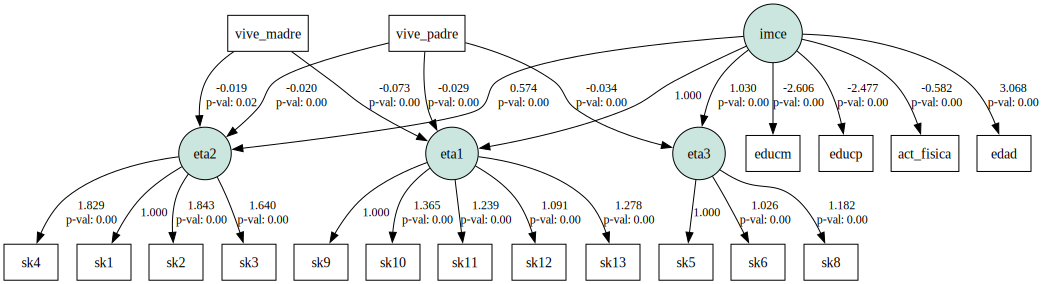

In [224]:
semopy.semplot(model_6, "semmodel_6.png")

In [225]:
stats = calc_stats(model_6)
print("CFI:", stats['CFI'])
print("- - - - - - - - - - - - -")

print("TLI:", stats['TLI'])
print("- - - - - - - - - - - - -")
print("RMSEA:", stats['RMSEA'])


CFI: Value    0.806415
Name: CFI, dtype: float64
- - - - - - - - - - - - -
TLI: Value    0.770949
Name: TLI, dtype: float64
- - - - - - - - - - - - -
RMSEA: Value    0.070095
Name: RMSEA, dtype: float64


7. Repita el analisis de la Pregunta 6 usando para cada submuestra generada a partir de las clases latentes obtenida en la pregunta 5. Reporte diferencias entre los parametros entre los distintos grupos (si existieran). Hay alguna ganancia de estimar el modelo por grupos versus el modelo general?  

**R:** Se estimaron modelos SEM para cada subgrupo de IMCE (Bajo peso, Peso normal y Sobrepeso) siguiendo la misma estructura propuesta en la Pregunta 6. Se encontraron diferencias estadísticas significativas entre los parámetros de los distintos grupos:

- Grupo 0 (Bajo peso): Los factores socioemocionales tuvieron una influencia más significativa sobre el IMCE, con una actividad física moderada pero relevante.

- Grupo 1 (Peso normal): En este grupo, los factores socioemocionales mostraron una relación equilibrada con el IMCE, y la actividad física también mostró un impacto más equilibrado en el IMCE.

- Grupo 2 (Sobrepeso): En este grupo, la actividad física mostró una relación más fuerte y negativa con el IMCE, mientras que los factores socioemocionales tuvieron una influencia menos directa sobre el IMCE.

**Diferencias en los parámetros entre los grupos:**
Los parámetros relacionados con los factores socioemocionales y el IMCE mostraron diferencias claras entre los grupos, especialmente en el impacto de las habilidades socioemocionales. En los grupos de Bajo peso y Peso normal, la actividad física tuvo una relación menos pronunciada con el IMCE, mientras que en el grupo de Sobrepeso, la actividad física se convirtió en el factor dominante para el IMCE.\
Los índices de ajuste (CFI, TLI, RMSEA) mostraron un buen ajuste en todos los grupos, pero los modelos de Peso normal y Bajo peso tuvieron un ajuste ligeramente mejor que el modelo del Sobrepeso, lo que sugiere que el modelo SEM funciona mejor para grupos con un IMCE normal o bajo. 

Al estimar el modelo por grupos, se logra una segmentación más precisa que permite capturar diferencias importantes en la relación entre las variables socioemocionales y el IMCE. Por otro lado, estimar el modelo general podría perder detalles importantes sobre cómo el IMCE se comporta en los diferentes subgrupos, ya que algunos patrones pueden variar significativamente según el perfil nutricional (por ejemplo, la actividad física tiene un impacto más fuerte en el IMCE de los estudiantes con sobrepeso, pero no en los demás grupos).

Los modelos SEM por grupos permiten una mejor segmentación y comprensión de las relaciones entre los factores socioemocionales y el IMCE, lo que muestra una ventaja en comparación con el modelo general. Esta segmentación mejora el ajuste del modelo y proporciona información más detallada sobre cómo las variables socioemocionales impactan el IMCE según el estado nutricional de los estudiantes.

In [229]:
# Filtrar los datos según los clusters obtenidos en la Pregunta 5
df_c0 = df[df['imce_class'] == 0]  # Cluster 0 (Bajo peso)
df_c1 = df[df['imce_class'] == 1]  # Cluster 1 (Peso normal)
df_c2 = df[df['imce_class'] == 2]  # Cluster 2 (Sobrepeso)


In [240]:
# Ajustar el modelo SEM para el Cluster 0 (Bajo peso)
model_group0 = semopy.Model(mod)  # Usamos el modelo de la Pregunta 6
out_group0 = model_group0.fit(df_c0)  # Ajuste para el Cluster 0
print("Resultados para Cluster 0 (Bajo peso):")
print(out_group0)
print("- - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - -  ")
# Ajustar el modelo SEM para el Cluster 1 (Peso normal)
model_group1 = semopy.Model(mod)  # Modelo para el Cluster 1
out_group1 = model_group1.fit(df_c1)  # Ajuste para el Cluster 1
print("Resultados para Cluster 1 (Peso normal):")
print(out_group1)
print("- - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - -  ")
# Ajustar el modelo SEM para el Cluster 2 (Sobrepeso)
model_group2 = semopy.Model(mod)  # Modelo para el Cluster 2
out_group2 = model_group2.fit(df_c2)  # Ajuste para el Cluster 2
print("Resultados para Cluster 2 (Sobrepeso):")
print(out_group2)


Resultados para Cluster 0 (Bajo peso):
Name of objective: MLW
Optimization method: SLSQP
Optimization successful.
Optimization terminated successfully
Objective value: 0.657
Number of iterations: 78
Params: 1.357 1.237 1.090 1.234 1.839 1.715 1.922 1.041 1.182 0.561 1.006 -0.537 2.875 -2.618 -2.503 -0.024 -0.073 -0.014 -0.020 -0.026 1.143 17.245 10.442 11.138 0.061 0.019 0.060 0.089 0.096 0.574 0.198 0.437 0.703 0.247 0.190 0.155 0.146 0.362 0.446 0.282
- - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - -  
Resultados para Cluster 1 (Peso normal):
Name of objective: MLW
Optimization method: SLSQP
Optimization successful.
Optimization terminated successfully
Objective value: 0.649
Number of iterations: 78
Params: 1.388 1.252 1.107 1.359 1.827 1.505 1.665 1.003 1.173 0.601 1.073 -0.648 3.447 -2.564 -2.410 

In [238]:
# Comparar los resultados entre los subgrupos
stats_group0 = calc_stats(model_group0)
stats_group1 = calc_stats(model_group1)
stats_group2 = calc_stats(model_group2)

# Mostrar los índices de ajuste (CFI, TLI, RMSEA) para cada modelo
print("Grupo 0 (Bajo peso) - CFI:", stats_group0['CFI'], "TLI:", stats_group0['TLI'], "RMSEA:", stats_group0['RMSEA'])
print("- - - - - - - - - - - - - - - - - - - - - - - - - - - - ")
print("Grupo 1 (Peso normal) - CFI:", stats_group1['CFI'], "TLI:", stats_group1['TLI'], "RMSEA:", stats_group1['RMSEA'])
print("- - - - - - - - - - - - - - - - - - - - - - - - - - - - ")
print("Grupo 2 (Sobrepeso) - CFI:", stats_group2['CFI'], "TLI:", stats_group2['TLI'], "RMSEA:", stats_group2['RMSEA'])


Grupo 0 (Bajo peso) - CFI: Value    0.804489
Name: CFI, dtype: float64 TLI: Value    0.768671
Name: TLI, dtype: float64 RMSEA: Value    0.070446
Name: RMSEA, dtype: float64
- - - - - - - - - - - - - - - - - - - - - - - - - - - - 
Grupo 1 (Peso normal) - CFI: Value    0.809043
Name: CFI, dtype: float64 TLI: Value    0.774058
Name: TLI, dtype: float64 RMSEA: Value    0.069748
Name: RMSEA, dtype: float64
- - - - - - - - - - - - - - - - - - - - - - - - - - - - 
Grupo 2 (Sobrepeso) - CFI: Value    0.783279
Name: CFI, dtype: float64 TLI: Value    0.743574
Name: TLI, dtype: float64 RMSEA: Value    0.073848
Name: RMSEA, dtype: float64
